In [35]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from bar_parallax_analytic_model import bar_parallax3D, bar_parallax1D


In [ ]:
import os

#v5 is with |l| < 5, 
#v6 is with all l
#v7 is |l|>1 and l<6 #my refininement based on data visualization relative to the bar model

plots_dir = "plotsv7    "
if not os.path.exists(plots_dir):
    os.makedirs(plots_dir)  


mcmcfit_dir = "mcmc_fitsv7"
if not os.path.exists(mcmcfit_dir):
    os.makedirs(mcmcfit_dir)

In [37]:
#dff = pd.read_csv('GaiaParallax/TotalAvg_Good_Single_Fits_s_0.33_level_0(2).csv')
#dff = pd.read_csv('/Users/himanshuverma/Downloads/combined_Gaia_data_0-55_sightline.zip', compression='zip')
#dff = pd.read_csv('/Users/himanshuverma/Downloads/combined_Gaia_data_0-55_sightline.csv.gz', compression='gzip')
dff1 = pd.read_csv('/Users/himanshuverma/Downloads/TotalAvg_Good_Single_Fits_s_0.33_level_0(3).csv')
display(dff1)
pd.set_option('display.max_columns', None)
dff2 = pd.read_csv('/Users/himanshuverma/Downloads/TotalAvg_Good_Single_Fits_s_0.55_level_0(1).csv')
display(dff2)

#merge the two dataframes 
dff = pd.concat([dff1, dff2], ignore_index=True).sort_values(by=['Latitude', 'Long']).reset_index(drop=True)
display(dff)

,Latitude,Long,Mean Parallax,Mean Parallax Error,Weighted Mean Parallax,Parallax Median,Parallax Mode,Parallax Dispersion,Parallax Clip Fraction,Number at parallax mean,Mean Magnitude,Magnitude Dispersion,Number at Mag mean,Mean Color,Color Dispersion,Number at color mean,RC Count,Magnitude Distinctness,D1Mag Distinctness,D2Mag Distinctness,Double Clump width,Color Distinctness,Distance Modulus,Red Clump Fraction,Red Clump Width,Red Clump 1 Width,Red Clump 2 Width,Most Common Pixel,Log of Zeropoint Count
0,-6.00,-9.90,0.116885,0.011884,0.123392,0.120863,0.076795,0.086788,0.810219,3.924708,16.293335,0.389889,48.048254,1.699727,0.101087,13.335330,91.00,1.423910,4.083893e+03,3.358650e+04,2.629548,0.619079,-0.338802,0.363415,0.386787,16.847943,19.990384,10.0,4.372783
1,-6.00,-9.57,0.130195,0.011257,0.146131,0.136144,0.115426,0.087954,0.775000,3.879868,16.268969,0.286743,24.698984,1.667206,0.170091,101.156925,68.00,0.738145,3.062808e+00,8.617321e+00,1.872041,12.045001,-0.572968,0.250183,0.281672,16.688334,18.950512,10.0,4.372783
2,-6.00,-8.91,0.147547,0.009551,0.147578,0.146340,0.187933,0.063896,0.733333,2.303983,16.155920,0.254684,25.666822,1.492230,0.146830,52.941493,69.00,0.971249,1.059334e+00,2.523969e+01,2.848544,12.685426,-0.844646,0.304588,0.250109,16.235429,19.681577,10.0,4.372783
3,-6.00,-8.58,0.127587,0.009270,0.123121,0.120565,0.118809,0.077907,0.768817,4.281835,16.256815,0.362896,54.103135,1.533340,0.124440,39.082707,114.00,1.072233,6.044451e-01,5.236783e+00,2.498003,14.814694,-0.529033,0.307586,0.360015,16.512847,19.352120,10.0,4.372783
4,-6.00,-8.25,0.120213,0.008094,0.122057,0.123269,0.122472,0.073748,0.797629,4.468829,16.223662,0.393240,48.602468,1.583118,0.125777,40.663010,121.00,0.879117,5.342741e+00,2.490617e+01,1.739459,5.083191,-0.398529,0.268248,0.389499,16.512657,18.860923,9.0,4.386047
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1076,4.89,8.58,0.164777,0.011340,0.162802,0.165777,0.180998,0.129061,0.852508,11.790788,17.185852,0.392125,74.164135,2.347729,0.122455,34.081159,230.00,1.072927,3.500644e+00,8.411099e+00,0.435487,45.162667,-1.083003,0.324147,0.389304,17.132527,17.628279,7.0,4.412629
1077,4.89,8.91,0.149221,0.010725,0.146839,0.147798,0.162130,0.110181,0.852065,8.635116,17.034167,0.312656,53.242199,2.350001,0.113625,28.725208,159.00,0.798707,3.776061e+00,1.894919e+01,0.058326,4.115270,-0.865266,0.270864,0.311729,17.216294,18.035816,7.0,4.412629
1078,4.89,9.24,0.150965,0.008354,0.150276,0.146836,0.130463,0.089752,0.827354,7.479461,16.810694,0.391168,79.650798,2.194473,0.124053,35.425681,178.75,1.052666,1.219198e+00,1.374817e+00,0.841820,4.405905,-0.892290,0.316738,0.387492,17.017130,17.826035,7.0,4.412629
1079,4.89,9.57,0.157269,0.008136,0.157152,0.161423,0.193338,0.102740,0.802263,9.976900,16.695409,0.440628,62.918105,2.104252,0.150927,48.730962,202.00,0.894025,3.144831e+11,2.586272e+11,1.452725,12.056198,-0.981668,0.280642,0.438358,17.298173,18.472642,7.0,4.412629


,Latitude,Long,Mean Parallax,Mean Parallax Error,Weighted Mean Parallax,Parallax Median,Parallax Mode,Parallax Dispersion,Parallax Clip Fraction,Number at parallax mean,Mean Magnitude,Magnitude Dispersion,Number at Mag mean,Mean Color,Color Dispersion,Number at color mean,RC Count,Magnitude Distinctness,D1Mag Distinctness,D2Mag Distinctness,Double Clump width,Color Distinctness,Distance Modulus,Red Clump Fraction,Red Clump Width,Red Clump 1 Width,Red Clump 2 Width,Most Common Pixel,Log of Zeropoint Count
0,-10.00,9.90,0.166451,0.006171,0.165176,0.165877,0.169716,0.059706,0.657534,3.616170,15.969548,0.427413,35.064933,1.476455,0.175669,38.924947,106.000000,0.560350,1.022519e+00,3.955123e-01,0.140439,0.901326,-1.106430,0.180806,0.421896,18.931127,18.593359,7.0,4.412629
1,-9.45,-1.65,0.113864,0.003695,0.113116,0.110397,0.110927,0.036733,0.717949,2.319584,15.726456,0.345508,27.440297,1.290817,0.104894,35.204167,100.000000,0.734500,4.002327e+00,2.846144e+00,1.404020,2.077582,-0.281929,0.239080,0.345258,16.537694,17.676050,7.0,4.412629
2,-9.45,4.95,0.132426,0.008695,0.135362,0.128167,0.123344,0.065036,0.695652,2.973269,16.028749,0.324531,19.021532,1.390194,0.114014,54.701242,86.000000,0.601543,9.796957e-01,3.625814e-01,1.199228,5.579435,-0.609869,0.203129,0.315441,16.505599,17.494797,7.0,4.412629
3,-9.45,8.80,0.143459,0.005084,0.144254,0.144306,0.143755,0.050087,0.718894,3.208303,15.964233,0.395662,103.354008,1.575082,0.152378,151.517833,115.000000,1.100288,3.490162e+00,7.153289e+00,0.881754,10.072168,-0.783639,0.312208,0.384256,17.474967,18.488007,7.0,4.412629
4,-9.45,9.35,0.144427,0.009879,0.150383,0.150698,0.174135,0.074439,0.750731,3.598510,15.938427,0.327571,21.159008,1.517370,0.140828,48.234040,97.500000,0.663067,1.600519e+03,5.035870e+04,2.277779,2.867802,-0.796684,0.222574,0.324289,17.066427,20.046631,7.0,4.412629
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119,-6.15,7.70,0.147773,0.003302,0.148175,0.146393,0.132780,0.062357,0.815445,10.961407,16.099772,0.335547,130.346004,1.757880,0.143153,90.208160,433.666667,1.229240,1.305387e+00,6.980152e+00,0.220507,359.309509,-0.847966,0.361618,0.334937,16.148225,16.700198,7.0,4.412629
120,-6.15,8.25,0.141453,0.003793,0.143133,0.141614,0.133570,0.065615,0.824238,10.050933,15.981297,0.327645,112.077966,1.676860,0.139559,78.777470,396.500000,0.991411,8.800284e-01,1.446876e-01,2.162202,774.006890,-0.752192,0.315625,0.327255,16.287612,18.306813,7.0,4.412629
121,-6.15,8.80,0.144704,0.004367,0.151280,0.151978,0.162300,0.073807,0.871237,10.998161,16.414869,0.368686,137.771475,1.962512,0.129714,63.969236,393.000000,1.068604,1.260771e+01,4.936250e+01,2.301692,4.115978,-0.802405,0.321770,0.366141,16.891643,19.772702,7.0,4.412629
122,-6.15,9.35,0.144495,0.004740,0.144233,0.145113,0.156724,0.072078,0.832618,9.962222,16.221961,0.351431,98.876345,1.844919,0.111630,49.590845,297.000000,0.826605,1.197694e+00,2.280067e-01,0.929558,1.911132,-0.799262,0.273276,0.350932,16.611449,17.203851,7.0,4.412629


,Latitude,Long,Mean Parallax,Mean Parallax Error,Weighted Mean Parallax,Parallax Median,Parallax Mode,Parallax Dispersion,Parallax Clip Fraction,Number at parallax mean,Mean Magnitude,Magnitude Dispersion,Number at Mag mean,Mean Color,Color Dispersion,Number at color mean,RC Count,Magnitude Distinctness,D1Mag Distinctness,D2Mag Distinctness,Double Clump width,Color Distinctness,Distance Modulus,Red Clump Fraction,Red Clump Width,Red Clump 1 Width,Red Clump 2 Width,Most Common Pixel,Log of Zeropoint Count
0,-10.00,9.90,0.166451,0.006171,0.165176,0.165877,0.169716,0.059706,0.657534,3.616170,15.969548,0.427413,35.064933,1.476455,0.175669,38.924947,106.00,0.560350,1.022519e+00,3.955123e-01,0.140439,0.901326,-1.106430,0.180806,0.421896,18.931127,18.593359,7.0,4.412629
1,-9.45,-1.65,0.113864,0.003695,0.113116,0.110397,0.110927,0.036733,0.717949,2.319584,15.726456,0.345508,27.440297,1.290817,0.104894,35.204167,100.00,0.734500,4.002327e+00,2.846144e+00,1.404020,2.077582,-0.281929,0.239080,0.345258,16.537694,17.676050,7.0,4.412629
2,-9.45,4.95,0.132426,0.008695,0.135362,0.128167,0.123344,0.065036,0.695652,2.973269,16.028749,0.324531,19.021532,1.390194,0.114014,54.701242,86.00,0.601543,9.796957e-01,3.625814e-01,1.199228,5.579435,-0.609869,0.203129,0.315441,16.505599,17.494797,7.0,4.412629
3,-9.45,8.80,0.143459,0.005084,0.144254,0.144306,0.143755,0.050087,0.718894,3.208303,15.964233,0.395662,103.354008,1.575082,0.152378,151.517833,115.00,1.100288,3.490162e+00,7.153289e+00,0.881754,10.072168,-0.783639,0.312208,0.384256,17.474967,18.488007,7.0,4.412629
4,-9.45,9.35,0.144427,0.009879,0.150383,0.150698,0.174135,0.074439,0.750731,3.598510,15.938427,0.327571,21.159008,1.517370,0.140828,48.234040,97.50,0.663067,1.600519e+03,5.035870e+04,2.277779,2.867802,-0.796684,0.222574,0.324289,17.066427,20.046631,7.0,4.412629
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1200,4.89,8.58,0.164777,0.011340,0.162802,0.165777,0.180998,0.129061,0.852508,11.790788,17.185852,0.392125,74.164135,2.347729,0.122455,34.081159,230.00,1.072927,3.500644e+00,8.411099e+00,0.435487,45.162667,-1.083003,0.324147,0.389304,17.132527,17.628279,7.0,4.412629
1201,4.89,8.91,0.149221,0.010725,0.146839,0.147798,0.162130,0.110181,0.852065,8.635116,17.034167,0.312656,53.242199,2.350001,0.113625,28.725208,159.00,0.798707,3.776061e+00,1.894919e+01,0.058326,4.115270,-0.865266,0.270864,0.311729,17.216294,18.035816,7.0,4.412629
1202,4.89,9.24,0.150965,0.008354,0.150276,0.146836,0.130463,0.089752,0.827354,7.479461,16.810694,0.391168,79.650798,2.194473,0.124053,35.425681,178.75,1.052666,1.219198e+00,1.374817e+00,0.841820,4.405905,-0.892290,0.316738,0.387492,17.017130,17.826035,7.0,4.412629
1203,4.89,9.57,0.157269,0.008136,0.157152,0.161423,0.193338,0.102740,0.802263,9.976900,16.695409,0.440628,62.918105,2.104252,0.150927,48.730962,202.00,0.894025,3.144831e+11,2.586272e+11,1.452725,12.056198,-0.981668,0.280642,0.438358,17.298173,18.472642,7.0,4.412629


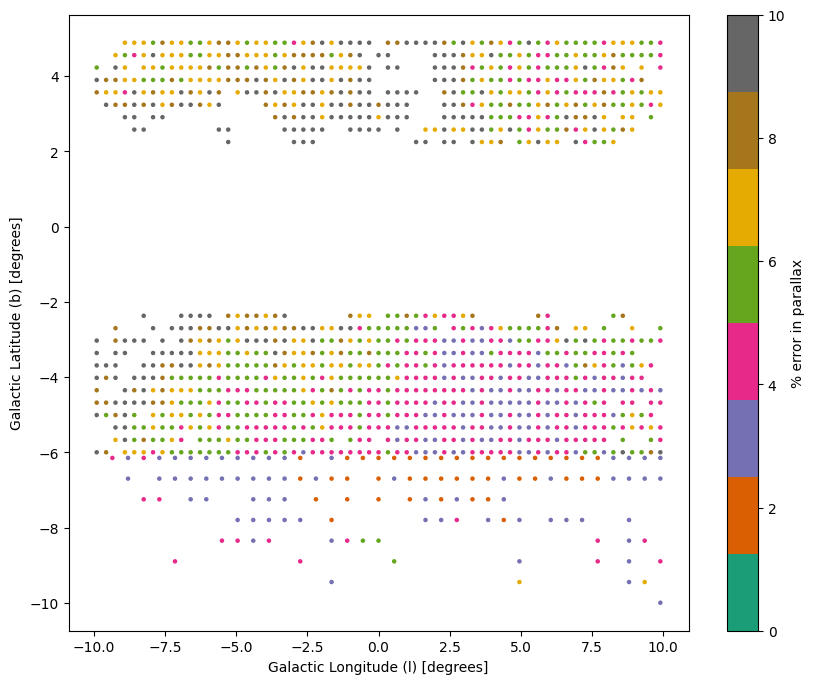

In [38]:
#draw 2d histogram of the data
plt.figure(figsize=(10, 8))
#plt.hist2d(dff['l'], dff['b'], bins=1000, cmap='plasma')
#plt.hist2d(dff['Long'], dff['Latitude'], bins=1000, cmap='plasma')
#plt.scatter(dff['l'], dff['b'], s=0.5, c=np.abs(dff['parallax_error']*100/dff['parallax']), cmap='Dark2', vmin=0,vmax=100)
plt.scatter(dff['Long'], dff['Latitude'], s=5, c=np.abs(dff['Mean Parallax Error']*100/dff['Mean Parallax']), cmap='Dark2', vmin=0,vmax=10)
plt.colorbar(label='% error in parallax')
#plt.colorbar(label='# of sources')
plt.xlabel('Galactic Longitude (l) [degrees]')
plt.ylabel('Galactic Latitude (b) [degrees]')
plt.show()

In [39]:
data=dff
df = data[(data['Magnitude Dispersion']<0.45) & (data['Magnitude Dispersion']>0.23) & (data['Magnitude Distinctness']>0.5) &
    (data['Color Dispersion']>0.1) & (data['Color Dispersion']<0.3) & (data['Mean Color']<2.2) 
    & (data['Long']>1) & (data['Long']<6) | (data['Long']<-1)    
    #& (data['Long']<5)& (data['Long']>-5)#v5 and v6 without this cut
    ]
df

,Latitude,Long,Mean Parallax,Mean Parallax Error,Weighted Mean Parallax,Parallax Median,Parallax Mode,Parallax Dispersion,Parallax Clip Fraction,Number at parallax mean,Mean Magnitude,Magnitude Dispersion,Number at Mag mean,Mean Color,Color Dispersion,Number at color mean,RC Count,Magnitude Distinctness,D1Mag Distinctness,D2Mag Distinctness,Double Clump width,Color Distinctness,Distance Modulus,Red Clump Fraction,Red Clump Width,Red Clump 1 Width,Red Clump 2 Width,Most Common Pixel,Log of Zeropoint Count
1,-9.45,-1.65,0.113864,0.003695,0.113116,0.110397,0.110927,0.036733,0.717949,2.319584,15.726456,0.345508,27.440297,1.290817,0.104894,35.204167,100.000000,0.734500,4.002327,2.846144,1.404020,2.077582,-0.281929,0.239080,0.345258,16.537694,17.676050,7.0,4.412629
2,-9.45,4.95,0.132426,0.008695,0.135362,0.128167,0.123344,0.065036,0.695652,2.973269,16.028749,0.324531,19.021532,1.390194,0.114014,54.701242,86.000000,0.601543,0.979696,0.362581,1.199228,5.579435,-0.609869,0.203129,0.315441,16.505599,17.494797,7.0,4.412629
5,-8.90,-7.15,0.115058,0.005214,0.115578,0.112119,0.096051,0.050685,0.723005,3.201708,15.662808,0.388812,20.563804,1.269500,0.115162,125.928214,114.000000,0.590755,0.050509,4.630715,0.000002,1.929657,-0.304579,0.196068,0.387647,19.998358,19.999725,7.0,4.412629
6,-8.90,-2.75,0.129693,0.006348,0.128159,0.122735,0.123224,0.059975,0.747573,3.740231,15.906818,0.424925,23.588201,1.291083,0.121185,17.373524,117.000000,0.615733,0.720021,0.148398,1.663105,0.414357,-0.564581,0.187739,0.417886,16.470632,17.747406,7.0,4.412629
8,-8.90,4.95,0.152356,0.005219,0.153218,0.154244,0.154404,0.048567,0.817204,2.922221,15.714943,0.233117,53.353348,1.502437,0.146751,125.646480,118.000000,1.132853,8.453659,19.568176,1.202577,41.664611,-0.914297,0.345315,0.232069,18.412906,19.383288,7.0,4.412629
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1169,4.89,-1.98,0.108053,0.010520,0.109773,0.105884,0.128458,0.189419,0.817973,31.701266,17.816448,0.374857,128.589034,2.622313,0.170821,76.653415,448.500000,1.322075,1.396264,0.652407,0.467979,5.260022,-0.151836,0.375151,0.373735,18.166508,18.356932,7.0,4.412629
1170,4.89,-1.65,0.128011,0.008970,0.126673,0.124629,0.110764,0.149561,0.819634,22.395971,17.602596,0.319687,84.759858,2.461603,0.136741,52.017380,380.666667,1.277150,0.998515,0.318009,0.208688,5.737384,-0.533468,0.374622,0.318509,17.888138,17.960934,7.0,4.412629
1171,4.89,-1.32,0.103655,0.011387,0.107560,0.109050,0.162350,0.194596,0.826152,33.457624,17.804496,0.336630,195.462817,2.624870,0.169821,61.391039,439.000000,1.173858,0.739983,0.991126,0.346382,8.818627,-0.077960,0.352714,0.335989,17.891636,18.300413,7.0,4.412629
1190,4.89,5.28,0.293994,0.057353,0.311821,0.315952,0.386141,0.274633,0.855997,13.659789,16.900537,0.385443,166.728360,1.876491,0.193122,-5801.543919,206.500000,1.489806,8.151445,6.521041,0.837980,387.447124,-2.016991,0.402264,0.378682,17.257576,18.319894,7.0,4.412629


In [40]:
# Check which rows are duplicates (returns boolean Series)
print(df.duplicated())

# Get all duplicate rows
display(df[df.duplicated()])

# Check duplicates including first occurrence
display(df[df.duplicated(keep=False)])

# Count number of duplicates
print(df.duplicated().sum())



1       False
2       False
5       False
6       False
8       False
        ...  
1169    False
1170    False
1171    False
1190    False
1192    False
Length: 696, dtype: bool


,Latitude,Long,Mean Parallax,Mean Parallax Error,Weighted Mean Parallax,Parallax Median,Parallax Mode,Parallax Dispersion,Parallax Clip Fraction,Number at parallax mean,Mean Magnitude,Magnitude Dispersion,Number at Mag mean,Mean Color,Color Dispersion,Number at color mean,RC Count,Magnitude Distinctness,D1Mag Distinctness,D2Mag Distinctness,Double Clump width,Color Distinctness,Distance Modulus,Red Clump Fraction,Red Clump Width,Red Clump 1 Width,Red Clump 2 Width,Most Common Pixel,Log of Zeropoint Count


,Latitude,Long,Mean Parallax,Mean Parallax Error,Weighted Mean Parallax,Parallax Median,Parallax Mode,Parallax Dispersion,Parallax Clip Fraction,Number at parallax mean,Mean Magnitude,Magnitude Dispersion,Number at Mag mean,Mean Color,Color Dispersion,Number at color mean,RC Count,Magnitude Distinctness,D1Mag Distinctness,D2Mag Distinctness,Double Clump width,Color Distinctness,Distance Modulus,Red Clump Fraction,Red Clump Width,Red Clump 1 Width,Red Clump 2 Width,Most Common Pixel,Log of Zeropoint Count


0


In [41]:
df.drop_duplicates()  # Keep first occurrence
df_u = df.drop_duplicates(keep='last')  # Keep last occurrence
display(df_u)

,Latitude,Long,Mean Parallax,Mean Parallax Error,Weighted Mean Parallax,Parallax Median,Parallax Mode,Parallax Dispersion,Parallax Clip Fraction,Number at parallax mean,Mean Magnitude,Magnitude Dispersion,Number at Mag mean,Mean Color,Color Dispersion,Number at color mean,RC Count,Magnitude Distinctness,D1Mag Distinctness,D2Mag Distinctness,Double Clump width,Color Distinctness,Distance Modulus,Red Clump Fraction,Red Clump Width,Red Clump 1 Width,Red Clump 2 Width,Most Common Pixel,Log of Zeropoint Count
1,-9.45,-1.65,0.113864,0.003695,0.113116,0.110397,0.110927,0.036733,0.717949,2.319584,15.726456,0.345508,27.440297,1.290817,0.104894,35.204167,100.000000,0.734500,4.002327,2.846144,1.404020,2.077582,-0.281929,0.239080,0.345258,16.537694,17.676050,7.0,4.412629
2,-9.45,4.95,0.132426,0.008695,0.135362,0.128167,0.123344,0.065036,0.695652,2.973269,16.028749,0.324531,19.021532,1.390194,0.114014,54.701242,86.000000,0.601543,0.979696,0.362581,1.199228,5.579435,-0.609869,0.203129,0.315441,16.505599,17.494797,7.0,4.412629
5,-8.90,-7.15,0.115058,0.005214,0.115578,0.112119,0.096051,0.050685,0.723005,3.201708,15.662808,0.388812,20.563804,1.269500,0.115162,125.928214,114.000000,0.590755,0.050509,4.630715,0.000002,1.929657,-0.304579,0.196068,0.387647,19.998358,19.999725,7.0,4.412629
6,-8.90,-2.75,0.129693,0.006348,0.128159,0.122735,0.123224,0.059975,0.747573,3.740231,15.906818,0.424925,23.588201,1.291083,0.121185,17.373524,117.000000,0.615733,0.720021,0.148398,1.663105,0.414357,-0.564581,0.187739,0.417886,16.470632,17.747406,7.0,4.412629
8,-8.90,4.95,0.152356,0.005219,0.153218,0.154244,0.154404,0.048567,0.817204,2.922221,15.714943,0.233117,53.353348,1.502437,0.146751,125.646480,118.000000,1.132853,8.453659,19.568176,1.202577,41.664611,-0.914297,0.345315,0.232069,18.412906,19.383288,7.0,4.412629
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1169,4.89,-1.98,0.108053,0.010520,0.109773,0.105884,0.128458,0.189419,0.817973,31.701266,17.816448,0.374857,128.589034,2.622313,0.170821,76.653415,448.500000,1.322075,1.396264,0.652407,0.467979,5.260022,-0.151836,0.375151,0.373735,18.166508,18.356932,7.0,4.412629
1170,4.89,-1.65,0.128011,0.008970,0.126673,0.124629,0.110764,0.149561,0.819634,22.395971,17.602596,0.319687,84.759858,2.461603,0.136741,52.017380,380.666667,1.277150,0.998515,0.318009,0.208688,5.737384,-0.533468,0.374622,0.318509,17.888138,17.960934,7.0,4.412629
1171,4.89,-1.32,0.103655,0.011387,0.107560,0.109050,0.162350,0.194596,0.826152,33.457624,17.804496,0.336630,195.462817,2.624870,0.169821,61.391039,439.000000,1.173858,0.739983,0.991126,0.346382,8.818627,-0.077960,0.352714,0.335989,17.891636,18.300413,7.0,4.412629
1190,4.89,5.28,0.293994,0.057353,0.311821,0.315952,0.386141,0.274633,0.855997,13.659789,16.900537,0.385443,166.728360,1.876491,0.193122,-5801.543919,206.500000,1.489806,8.151445,6.521041,0.837980,387.447124,-2.016991,0.402264,0.378682,17.257576,18.319894,7.0,4.412629


In [42]:
#choose unique latitudes
unique_latitudes = df['Latitude'].unique()
print(unique_latitudes, len(unique_latitudes))
unique_longitudes = df['Long'].unique()
print(unique_longitudes, len(unique_longitudes))
print(6*58)

[-9.45 -8.9  -8.35 -7.8  -7.25 -6.7  -6.15 -6.15 -6.   -5.67 -5.67 -5.34
 -5.01 -4.68 -4.35 -4.02 -3.69 -3.36 -3.03 -2.7  -2.7  -2.37  2.25  2.58
  2.91  3.24  3.57  3.9   4.23  4.56  4.89] 31
[-1.65  4.95 -7.15 -2.75 -5.5  -4.95 -4.4  -3.85 -1.1  -3.3   1.65  2.2
  2.75  3.85  4.4  -8.25 -7.7  -6.6  -6.05 -2.2   1.1   3.3  -8.8   5.5
 -9.35 -9.9  -9.57 -8.91 -8.58 -7.92 -7.59 -7.26 -6.93 -6.27 -5.94 -5.61
 -5.28 -4.62 -4.29 -3.96 -3.63 -2.97 -2.64 -2.31 -1.98 -1.32  1.32  1.98
  2.31  2.64  2.97  3.63  3.96  4.29  4.62  5.28  5.61  5.94 -9.24] 59
348


/var/folders/8l/p90_cj915l7dtkqz4wc5w59r0000gn/T/ipykernel_45834/428413461.py:41: RuntimeWarning: divide by zero encountered in divide
  axsec = ax.secondary_yaxis('right', functions=(lambda x: 1/x, lambda x: 1/x))


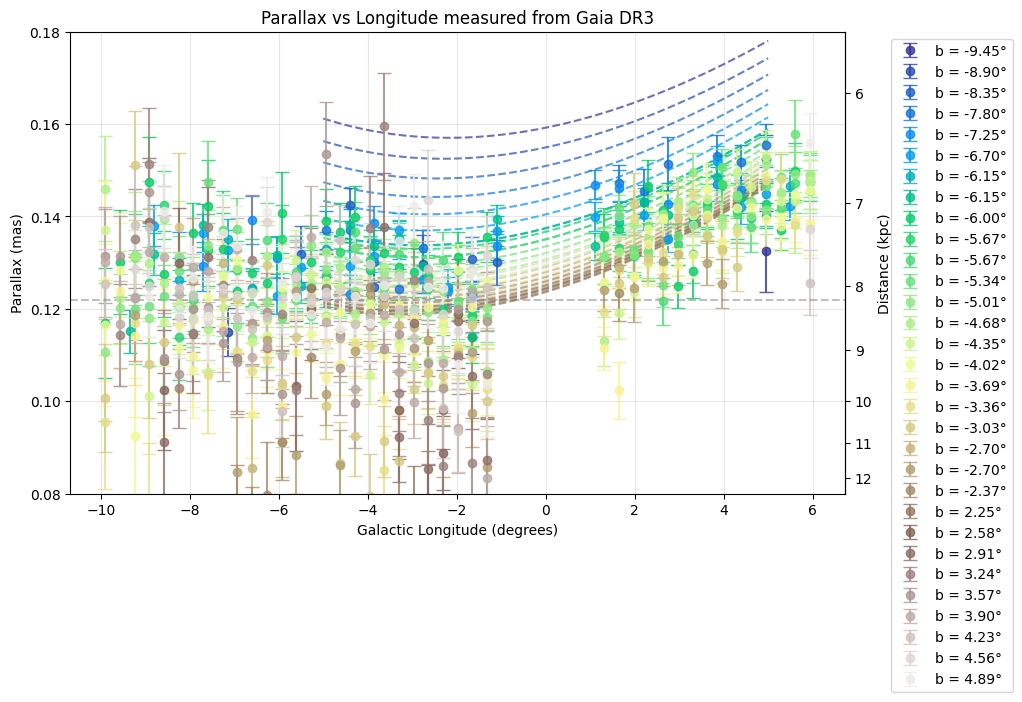

In [43]:
fig = plt.figure(figsize=(10, 6))

#define user defined colors for each latitude
colors = plt.colormaps['terrain'](np.linspace(0, 1, len(unique_latitudes)+1))

ax = fig.add_subplot(1, 1, 1)
custom_params = {
    'sigma_x': 0.83,  # Longer bar major axis
    'sigma_y': 0.21,  # Shorter bar minor axis
    'sigma_z': 0.22,  # Thinner bar vertically
    'r_E': 8.16,       # Closer bar center
    's_max': 15.0,     # Max distance from us for averaging
    #'epsrel': 1e-6    # Relative error tolerance for integration
}
Al = np.linspace(-5, 5, 50)  # Galactic longitude range for plotting
for fixed_b_deg in unique_latitudes:
    df_u_lat = df_u[df_u['Latitude'] == fixed_b_deg]


    longitude_range = df_u_lat['Long']
    parallax_data = df_u_lat['Mean Parallax']
    parallax_error = df_u_lat['Mean Parallax Error']
    analytic_parallaxes = [bar_parallax3D(l, fixed_b_deg, 6.49, **custom_params) for l in Al]
    ax.errorbar(longitude_range, parallax_data, 
                yerr=parallax_error, 
                fmt='o', alpha=0.8,
                color=colors[unique_latitudes.tolist().index(fixed_b_deg)], 
                capsize=5, markersize=6, label=f'b = {fixed_b_deg:.2f}°')
    ax.plot(Al, analytic_parallaxes, 
            '--',color=colors[unique_latitudes.tolist().index(fixed_b_deg)], alpha=0.7)
ax.set_xlabel('Galactic Longitude (degrees)')
ax.set_ylabel(f'Parallax (mas)')
ax.set_title(f'Parallax vs Longitude measured from Gaia DR3')
ax.grid(True, alpha=0.3)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
#ax.set_xlim(-16, 16)
ax.set_ylim(0.08, 0.18)

ax.axhline(1/8.2, color='gray', linestyle='--', alpha=0.5)

axsec = ax.secondary_yaxis('right', functions=(lambda x: 1/x, lambda x: 1/x))
axsec.set_ylabel('Distance (kpc)')

fig.savefig(os.path.join(plots_dir, f'GaiaDR3_parallax_vs_longitude.png'), dpi=300)
plt.show()

# Focused run:

- For each strip of b:
    - run mcmc with priors on all except bar angle
    - run mcmc without priors except rE and sigma_z
    
- For all b values together:
    - run mcmc with priors on all except bar angle
    - run mcmc without priors except rE and sigma_z
    - run mcmc without priors except rE


In [10]:
from bar_angle_fitter import BarAngleFitter

model_params = {
    'sigma_x': {'mean': 0.67, 'std': 0.1},
    'sigma_y': {'mean': 0.29, 'std': 0.05},
    'sigma_z': {'mean': 0.27, 'std': 0.05},
    'r_E': {'mean': 8.2, 'std': 0.2},
    's_max': 15.0  # Always fixed
}

for fixed_b_deg in unique_latitudes:
    df_u_lat = df_u[df_u['Latitude'] == fixed_b_deg]

    longitude_range = df_u_lat['Long']
    parallax_data = df_u_lat['Mean Parallax']
    parallax_error = df_u_lat['Mean Parallax Error']

    fitter = BarAngleFitter(
        parallax_data=parallax_data,
        parallax_error=parallax_error,
        l_values=longitude_range,
        b_values=fixed_b_deg,
        model_params=model_params,
        fit_params=['bar_angle', 'zp', 'sigma_x', 'sigma_y', 'sigma_z', 'r_E']
    )

    # Run MCMC
    samples = fitter.run_mcmc(n_walkers=12, n_steps=2000, n_burn=100)
    # save MCMC samples
    np.save(os.path.join(mcmcfit_dir, f'AllPriors_MCMCsamples_b_{fixed_b_deg:.2f}.npy'), samples)
    chains = fitter.chains
    np.save(os.path.join(mcmcfit_dir, f'AllPriors_MCMCchains_b_{fixed_b_deg:.2f}.npy'), chains)

100%|██████████| 2000/2000 [13:04<00:00,  2.55it/s]


In [11]:
from bar_angle_fitter import BarAngleFitter

model_params = {
    'sigma_x': 0.67,
    'sigma_y': 0.29,
    'sigma_z': {'mean': 0.27, 'std': 0.05},
    'r_E': {'mean': 8.2, 'std': 0.2},
    's_max': 15.0  # Always fixed
}

for fixed_b_deg in unique_latitudes:
    df_u_lat = df_u[df_u['Latitude'] == fixed_b_deg]


    longitude_range = df_u_lat['Long']
    parallax_data = df_u_lat['Mean Parallax']
    parallax_error = df_u_lat['Mean Parallax Error']

    fitter = BarAngleFitter(
        parallax_data=parallax_data,
        parallax_error=parallax_error,
        l_values=longitude_range,
        b_values=fixed_b_deg,
        model_params=model_params,
        fit_params=['bar_angle', 'zp', 'sigma_x', 'sigma_y', 'sigma_z', 'r_E']
    )

    # Run MCMC
    samples = fitter.run_mcmc(n_walkers=12, n_steps=2000, n_burn=100, priors_range={'sigma_x': (0.1, 2), 'sigma_y': (0.1, 1)})
    # save MCMC samples
    np.save(os.path.join(mcmcfit_dir, f'sigZrEPriors_MCMCsamples_b_{fixed_b_deg:.2f}.npy'), samples)
    np.save(os.path.join(mcmcfit_dir, f'sigZrEPriors_MCMCchains_b_{fixed_b_deg:.2f}.npy'), fitter.chains)


100%|██████████| 2000/2000 [07:37<00:00,  4.37it/s]


In [12]:
from bar_angle_fitter import BarAngleFitter
model_params = {
    'sigma_x': {'mean': 0.67, 'std': 0.1},
    'sigma_y': {'mean': 0.29, 'std': 0.05},
    'sigma_z': {'mean': 0.27, 'std': 0.05},
    'r_E': {'mean': 8.2, 'std': 0.2},
    's_max': 15.0  # Always fixed
}

longitude_range = df_u['Long']
latitude_range = df_u['Latitude']
parallax_data = df_u['Mean Parallax']
parallax_error = df_u['Mean Parallax Error']


fitter = BarAngleFitter(
    parallax_data=parallax_data,
    parallax_error=parallax_error,
    l_values=longitude_range,
    b_values=latitude_range,
    model_params=model_params,
    fit_params=['bar_angle', 'zp', 'sigma_x', 'sigma_y', 'sigma_z', 'r_E']
)

# Run MCMC
samples=fitter.run_mcmc(n_walkers=12, n_steps=2000, n_burn=100)
# save MCMC samples
np.save(os.path.join(mcmcfit_dir, f'AllPriors_MCMCsamples_all_b.npy'), samples)
np.save(os.path.join(mcmcfit_dir, f'AllPriors_MCMCchains_all_b.npy'), fitter.chains)

100%|██████████| 2000/2000 [5:05:21<00:00,  9.16s/it]  


In [13]:
from bar_angle_fitter import BarAngleFitter

model_params = {
    'sigma_x': 0.67,
    'sigma_y': 0.29,
    'sigma_z': {'mean': 0.27, 'std': 0.05},
    'r_E': {'mean': 8.2, 'std': 0.2},
    's_max': 15.0  # Always fixed
}
longitude_range = df_u['Long']
latitude_range = df_u['Latitude']
parallax_data = df_u['Mean Parallax']
parallax_error = df_u['Mean Parallax Error']


fitter = BarAngleFitter(
    parallax_data=parallax_data,
    parallax_error=parallax_error,
    l_values=longitude_range,
    b_values=latitude_range,
    model_params=model_params,
    fit_params=['bar_angle', 'zp', 'sigma_x', 'sigma_y', 'sigma_z', 'r_E']
)

# Run MCMC
samples=fitter.run_mcmc(n_walkers=12, n_steps=2000, n_burn=100, priors_range={'sigma_x': (0.1, 2), 'sigma_y': (0.1, 1)})
# save MCMC samples
np.save(os.path.join(mcmcfit_dir, f'sigZrEPriors_MCMCsamples_all_b.npy'), samples)
np.save(os.path.join(mcmcfit_dir, f'sigZrEPriors_MCMCchains_all_b.npy'), fitter.chains)

100%|██████████| 2000/2000 [4:19:54<00:00,  7.80s/it]  


In [44]:
from bar_angle_fitter import BarAngleFitter

model_params = {
    'sigma_x': 0.67,
    'sigma_y': 0.29,
    'sigma_z': 0.27,
    'r_E': {'mean': 8.2, 'std': 0.2},
    's_max': 15.0  # Always fixed
}
longitude_range = df_u['Long']
latitude_range = df_u['Latitude']
parallax_data = df_u['Mean Parallax']
parallax_error = df_u['Mean Parallax Error']


fitter = BarAngleFitter(
    parallax_data=parallax_data,
    parallax_error=parallax_error,
    l_values=longitude_range,
    b_values=latitude_range,
    model_params=model_params,
    fit_params=['bar_angle', 'zp', 'sigma_x', 'sigma_y', 'sigma_z', 'r_E']
)

# Run MCMC
samples=fitter.run_mcmc(n_walkers=12, n_steps=2000, n_burn=100, priors_range={'sigma_x': (0.1, 2), 'sigma_y': (0.1, 1), 'sigma_z': (0.1, 1)})
# save MCMC samples
np.save(os.path.join(mcmcfit_dir, f'rEPriors_MCMCsamples_all_b.npy'), samples)
np.save(os.path.join(mcmcfit_dir, f'rEPriors_MCMCchains_all_b.npy'), fitter.chains)


100%|██████████| 2000/2000 [4:25:19<00:00,  7.96s/it]  


# Discuss:
- plots
- model given in https://arxiv.org/pdf/1303.6430 1-5 equations. We have used nG1 model according to their nomenclature.


# to do
- No prior run
- Running with prior on rE, sigma_z
- Run with priors on sigma_x, sigma_y, sigma_z, rE


- Running with individual strips (i.e. b=fixed)
    - No prior run
    - Running with prior on rE, sigma_z
    - Run with priors on sigma_x, sigma_y, sigma_z, rE

- Run with all combination of (l,b) with sigma_z free

- Origin of correlation needs to be explained/examined



- Running with all combination of (l,b)
    - No prior run
    - Running with prior on rE, sigma_z
    - Run with priors on sigma_x, sigma_y, sigma_z, rE


- Store chi2 and dof for each run
- Maybe store chains and then derive 
    - Compute covariance matrix of the parameters as well.
    - best fit
